In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
from statsmodels.stats.multitest import multipletests

In [2]:
genome=[30427671,19698289,23459830,18585056,26975502]
space=2000000
chr1=30427671 / 2 
chr2=30427671 + 19698289 / 2 + space
chr3=30427671 + 19698289 + 23459830 / 2 + space * 2
chr4=30427671 + 19698289 + 23459830 + 18585056 / 2 + space * 3
chr5=30427671 + 19698289 + 23459830 + 18585056 + 26975502 / 2 + space * 4

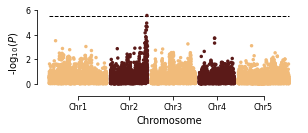

In [15]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    return(df)
classic=parse('SA_leaf_B_blues.assoc.txt.gz')
cm = 1/2.54
# fig = plt.figure(figsize=(16,4))
fig = plt.figure(figsize=(12*cm,4*cm))
ax = sns.scatterplot(x='position',
                y='P',
                data=classic,
                hue='chr',
                palette=['#F1BB7A','#5B1A18','#F1BB7A','#5B1A18','#F1BB7A'],
                marker='o',
                s=12,
                linewidth=0,
                legend=False,
                zorder=2)
plt.hlines(y=-np.log10(0.05/len(classic)),
             xmin=min(classic['position']),
             xmax=max(classic['position']),
             color='0',
             linestyle='--',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
plt.xlabel('Chromosome',fontsize=10)
plt.ylim(-1,6)
plt.ylabel('-log$_{10}$($\itP$)',fontsize=10)
plt.xticks([chr1,chr2,chr3,chr4,chr5],["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"])
sns.despine(trim=True)
plt.tick_params(labelsize=8)
# plt.savefig("GWAS_SA_zscore3_B-Cr-Ti_20250329.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)

In [16]:
-np.log10(0.05/len(classic))

5.542476856009627

In [17]:
classic.sort_values(by='P',ascending=False)

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
7476,2,2:19374681,19374681,3,T,T,0.475,3.309266,0.604805,2.804643,2.781887,2.447684e-07,0.000003,0.000091,5.566796,-5.566796,51802352
7452,2,2:19253995,19253995,1,T,G,0.426,3.332804,0.691135,3.979145,3.956150,4.173675e-06,0.000011,0.000111,4.945896,-4.945896,51681666
7410,2,2:18947614,18947614,2,G,C,0.471,3.147444,0.651124,3.370167,3.349985,3.974102e-06,0.000020,0.000248,4.688673,-4.688673,51375285
7434,2,2:19140911,19140911,6,A,C,0.436,3.152357,0.656326,3.455970,3.458324,4.523730e-06,0.000021,0.000255,4.676485,-4.676485,51568582
7492,2,2:19477608,19477608,2,C,A,0.430,3.242402,0.699442,4.079402,4.059403,9.057824e-06,0.000023,0.000181,4.638306,-4.638306,51905279
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11837,4,4:6802480,6802480,7,A,T,0.414,-0.001509,0.737400,7.779649,7.880073,9.983708e-01,0.999603,0.999604,0.000173,-0.000173,86388270
5267,2,2:4831831,4831831,3,T,T,0.283,-0.000965,0.908747,7.803865,7.880280,9.991542e-01,0.999617,0.999618,0.000166,-0.000166,37259502
8021,3,3:3732582,3732582,2,C,T,0.339,-0.001040,0.815907,7.837642,7.880059,9.989849e-01,0.999638,0.999640,0.000157,-0.000157,57858542
9475,3,3:14157451,14157451,6,C,T,0.316,0.004784,0.973870,7.755787,7.879982,9.960890e-01,0.999662,0.999666,0.000147,-0.000147,68283411


In [18]:
import statsmodels.stats.multitest as smm
import numpy as np
from statsmodels.stats.multitest import multipletests
rejected, pvals_corrected, _, _ = multipletests(classic['p_lrt'], alpha=0.1, method='fdr_bh')

In [19]:
classic["Significant"] = rejected
classic["FDR_corrected_pval"] = pvals_corrected

In [20]:
classic[classic["Significant"] == True]

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position,Significant,FDR_corrected_pval
7410,2,2:18947614,18947614,2,G,C,0.471,3.147444,0.651124,3.370167,3.349985,3.974102e-06,0.000020,0.000248,4.688673,-4.688673,51375285,True,0.080199
7434,2,2:19140911,19140911,6,A,C,0.436,3.152357,0.656326,3.455970,3.458324,4.523730e-06,0.000021,0.000255,4.676485,-4.676485,51568582,True,0.080199
7452,2,2:19253995,19253995,1,T,G,0.426,3.332804,0.691135,3.979145,3.956150,4.173675e-06,0.000011,0.000111,4.945896,-4.945896,51681666,True,0.080199
7476,2,2:19374681,19374681,3,T,T,0.475,3.309266,0.604805,2.804643,2.781887,2.447684e-07,0.000003,0.000091,5.566796,-5.566796,51802352,True,0.047277
7492,2,2:19477608,19477608,2,C,A,0.430,3.242402,0.699442,4.079402,4.059403,9.057824e-06,0.000023,0.000181,4.638306,-4.638306,51905279,True,0.080199


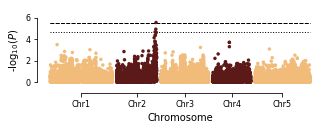

In [22]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    return(df)
# classic=parse('SA_leaf_B_blues_kship.assoc.txt.gz')
cm = 1/2.54
# fig = plt.figure(figsize=(16,4))
fig = plt.figure(figsize=(13*cm,4*cm))
ax = sns.scatterplot(x='position',
                y='P',
                data=classic,
                hue='chr',
                palette=['#F1BB7A','#5B1A18','#F1BB7A','#5B1A18','#F1BB7A'],
                marker='o',
                s=12,
                linewidth=0,
                legend=False,
                zorder=2)
plt.hlines(y=-np.log10(0.05/len(classic)),
             xmin=min(classic['position']),
             xmax=max(classic['position']),
             color='0',
             linestyle='--',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
plt.hlines(y=-np.log10(0.05/len(classic)),
             xmin=min(classic['position']),
             xmax=max(classic['position']),
             color='0',
             linestyle='--',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
plt.hlines(y=classic[classic["Significant"] == True]['P'].min(),
             xmin=min(classic['position']),
             xmax=max(classic['position']),
             color='0',
             linestyle=':',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
plt.xlabel('Chromosome',fontsize=10)
plt.ylim(-1,7)
plt.ylabel('-log$_{10}$($\itP$)',fontsize=10)
plt.xticks([chr1,chr2,chr3,chr4,chr5],["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"])
sns.despine(trim=True)
plt.tick_params(labelsize=8)
plt.savefig("Fig2a.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)

In [23]:
classic.loc[classic['chr'] == 2].sort_values(by=['P'],ascending=False).head(5)

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position,Significant,FDR_corrected_pval
7476,2,2:19374681,19374681,3,T,T,0.475,3.309266,0.604805,2.804643,2.781887,2.447684e-07,0.000003,0.000091,5.566796,-5.566796,51802352,True,0.047277
7452,2,2:19253995,19253995,1,T,G,0.426,3.332804,0.691135,3.979145,3.956150,4.173675e-06,0.000011,0.000111,4.945896,-4.945896,51681666,True,0.080199
7410,2,2:18947614,18947614,2,G,C,0.471,3.147444,0.651124,3.370167,3.349985,3.974102e-06,0.000020,0.000248,4.688673,-4.688673,51375285,True,0.080199
7434,2,2:19140911,19140911,6,A,C,0.436,3.152357,0.656326,3.455970,3.458324,4.523730e-06,0.000021,0.000255,4.676485,-4.676485,51568582,True,0.080199
7492,2,2:19477608,19477608,2,C,A,0.430,3.242402,0.699442,4.079402,4.059403,9.057824e-06,0.000023,0.000181,4.638306,-4.638306,51905279,True,0.080199
